# Compound Cueing CRP

> Compute and visualize compound cueing conditional response probabilities for repeated items.

The compound cueing analysis tests a prediction that differentiates composite memory models (CMR) from instance-based models (ICMR). For a repeated item at study positions $i$ and $j$ (with sufficient spacing), the analysis examines how the *two most recent* recalls influence the probability of transitioning to the repeated item.

- **Pure cueing**: last two recalls are $\{i\!-\!2,\, i\!-\!1\}$ or $\{j\!-\!2,\, j\!-\!1\}$ (both from one occurrence's neighborhood)
- **Mixed cueing**: last two recalls are $\{j\!-\!2,\, i\!-\!1\}$ or $\{i\!-\!2,\, j\!-\!1\}$ (one from each occurrence's neighborhood)

CMR ($\tau = 1$) predicts mixed cueing provides equal or greater support because similarities sum linearly. ICMR ($\tau > 1$) predicts pure cueing provides greater support because sharpening occurs before summing [@lohnas2014retrieved].

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.compound_cueing_crp import (
    CompoundCueingTabulation,
    compound_cueing_crp,
    plot_compound_cueing,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "compound_cueing"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = 'data["list_type"] > 2'

In [4]:
#| code-summary: Load data and generate trial mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

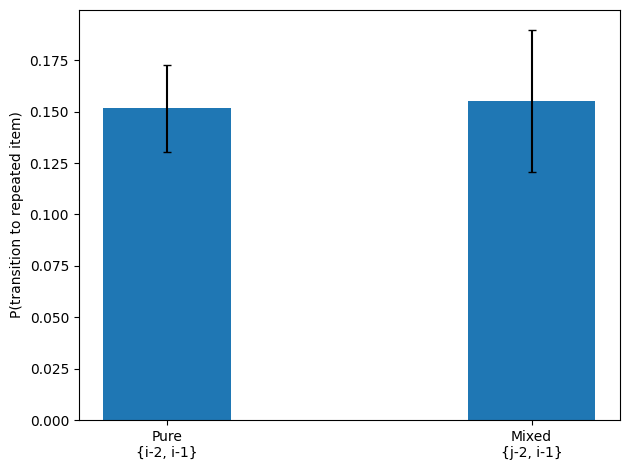

In [5]:
#| code-summary: Plot compound cueing CRP
#| label: fig-compound-cueing
#| fig-cap: "Compound cueing CRP comparing pure vs mixed cueing conditions."
plot_compound_cueing(data, trial_mask)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_compound_cueing)

---

### plot_compound_cueing

>      plot_compound_cueing (datasets:Union[Sequence[jaxcmr.typing.RecallDataset
>                            ],jaxcmr.typing.RecallDataset], trial_masks:Union[S
>                            equence[jaxtyping.Bool[Array,'trial_count']],jaxtyp
>                            ing.Bool[Array,'trial_count']], min_spacing:int=6,
>                            size:int=2, color_cycle:Optional[list[str]]=None,
>                            labels:Optional[Sequence[str]]=None,
>                            contrast_name:Optional[str]=None,
>                            axis:Optional[matplotlib.axes._axes.Axes]=None)

*Plot compound cueing as a grouped bar chart.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| min_spacing | int | 6 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum positions an item can occupy. |
| color_cycle | Optional | None | Colors for each dataset. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| **Returns** | **Axes** |  | **Axes with bar plot comparing pure vs mixed cueing.** |

In [7]:
#| echo: false
show_doc(compound_cueing_crp)

---

### compound_cueing_crp

>      compound_cueing_crp (dataset:jaxcmr.typing.RecallDataset,
>                           min_spacing:int=6, size:int=2)

*Compute compound cueing conditional response probabilities.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset with ``recalls`` and ``pres_itemnos``. |
| min_spacing | int | 6 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum positions an item can occupy. |
| **Returns** | **Float[Array, '2']** |  | **[pure_crp, mixed_crp]; NaN where no opportunities.** |

In [8]:
# No-repeat lists produce NaN for both conditions
presentation = jnp.array([[1, 2, 3, 4, 5, 6, 7, 8]], dtype=jnp.int32)
trial = jnp.array([[1, 2, 3, 4, 5, 6, 7, 8]], dtype=jnp.int32)

dataset = {
    "subject": jnp.ones((1, 1), dtype=jnp.int32),
    "listLength": jnp.full((1, 1), 8, dtype=jnp.int32),
    "pres_itemnos": presentation,
    "recalls": trial,
}

result = compound_cueing_crp(dataset, min_spacing=6, size=2)
assert jnp.isnan(result[0])  # pure_crp = NaN (no repeated items)
assert jnp.isnan(result[1])  # mixed_crp = NaN

### Tabulation

The CRP function aggregates trial-level tabulations. `tabulate_trial` processes a single trial, accumulating pure and mixed actual/available counts across recall events.

In [9]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      min_spacing:int=6, size:int=2)

*Tabulate compound cueing counts for a single trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Recalled item numbers (1-indexed; 0 = padding). |
| presentation | Integer[Array, 'study_events'] |  | Item numbers at each study position. |
| min_spacing | int | 6 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum positions an item can occupy. |
| **Returns** | **Integer[Array, '4']** |  | **Counts [pure_actual, pure_avail, mixed_actual,<br>mixed_avail].** |

In [10]:
# Non-repeated items contribute zero counts
presentation = jnp.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=jnp.int32)
trial = jnp.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=jnp.int32)
counts = tabulate_trial(trial, presentation, min_spacing=6, size=2)
assert jnp.all(counts == 0)

# Items with insufficient spacing are also ignored
presentation_close = jnp.array([1, 2, 3, 1, 5, 6, 7, 8], dtype=jnp.int32)
trial_close = jnp.array([2, 3, 1, 0, 0, 0, 0, 0], dtype=jnp.int32)
counts_close = tabulate_trial(trial_close, presentation_close, min_spacing=6, size=2)
assert jnp.all(counts_close == 0)

In [11]:
# Random recall patterns yield no cueing counts
presentation = jnp.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 3, 10, 11], dtype=jnp.int32)
trial = jnp.array([4, 6, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=jnp.int32)
counts = tabulate_trial(trial, presentation, min_spacing=6, size=2)
pure_actual, pure_avail, mixed_actual, mixed_avail = counts
assert pure_avail == 0
assert mixed_avail == 0